In [414]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
from scipy.fftpack import idct


Variable initialization

In [415]:
N = 32 # signal dimension
M = 32 # number of atoms in the span (for basis M = N)

C = np.zeros((N, M)) # matrix containing the standard basis (a kronecker delta in each column)
D = np.zeros((N, M)) # matrix containing the DCT basis (a DCT function in each column)


Generate the 1D-DCT basis

Text(0.5, 1.0, 'DCT basis')

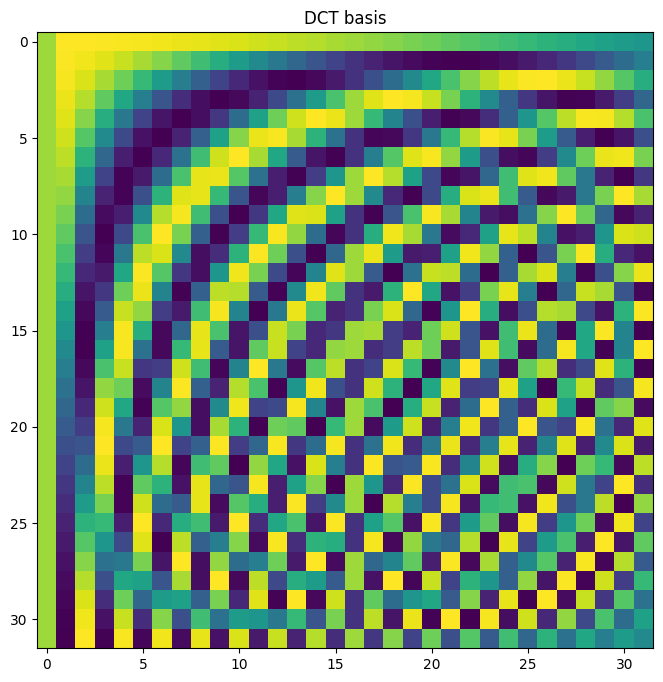

In [416]:
for i in range(M):
    a = np.zeros(N)
    a[i] = 1
    D[:, i] = idct(a, norm='ortho')

plt.figure(figsize=(8,8))
plt.imshow(D)
plt.title('DCT basis')

# Sparsity w.r.t orthonormal basis DCT

In this section you will perform denoising of a signal that is *sparse* w.r.t. the orthornormal basis $D\in\mathbb{R}^{N\times N}$, i.e., the 1D-DCT basis.

At first, generate a vector $x_{orig}\in\mathbb{R}^N$ that is $L$-sparse, i.e. $\|x_{orig}\|_0 = L$. Use this coefficient vector $x_{orig}$, generate a noise-free signal $y\in\mathbb{R}^N$ as $y=Dx_{orig}$, and add some Gaussian noise to obtain $s = y + \eta$.

Perform the DCT denoising on the noisy signal $s$ to recover $\hat y$. Use the Hard Thresholding operator that keeps only the largest $L$ coefficients and evaluate the denoising performance


Set the sparsity level $L$

In [417]:
L = 3

Randomly define the coefficients of a sparse representation $x$ (make sure the nonzero coefficients are sufficiently large)

In [418]:
x_orig = np.zeros(M)
for i in range(L):
    loc = np.random.randint(M-1)
    if x_orig[loc] != 0:
        i= i -1
    x_orig[loc] = np.random.randint(1,100) # Change the coefficient

print(x_orig)

[ 0.  0.  0. 64.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 52.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.]


Synthetize the corresponding signal in the signal domain and add noise


In [419]:
y = D @ x_orig

s = y + np.random.normal(0,1,M)

Plot the sparse signal

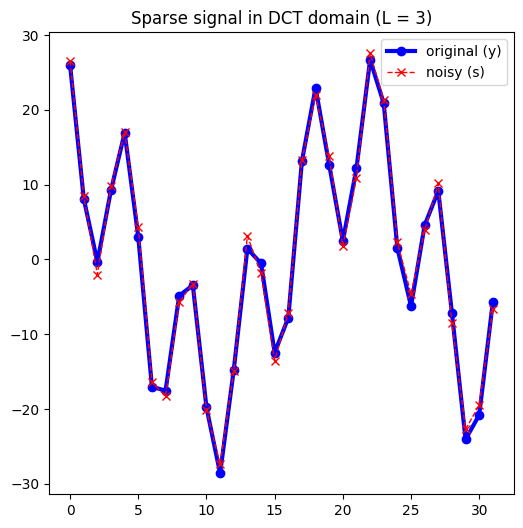

In [420]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6,6))
plt.plot(y, 'b-o', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original (y)', 'noisy (s)'])


### Implement the DCT denoising

DCT denoising is expected to be very effective on $s$!

**Analysis**: compute the coefficients w.r.t. $D$

In [421]:
x = D.T @ s

**Hard Thresholding**: keep only the $L$ largest coefficients (absolute value)

In [422]:
thresh = np.sort(np.abs(x))[-L]

x_hat = x * (np.abs(x)>= thresh)
x_hat[0] = x[0]

print(x_hat)

[ 0.62335509 -0.          0.         63.812725   -0.          0.
 -0.         -0.         -0.         -0.          0.          2.08962962
 -0.          0.         51.89378995  0.         -0.          0.
 -0.          0.          0.         -0.         -0.          0.
 -0.         -0.          0.         -0.          0.         -0.
 -0.         -0.        ]


**Synthesis**: invert the transform

In [423]:
s_hat = D @ x_hat

Plot the results:
- are the denoising performance good?
- are the original coefficients $x_{orig}$ recovered by $\hat x$?

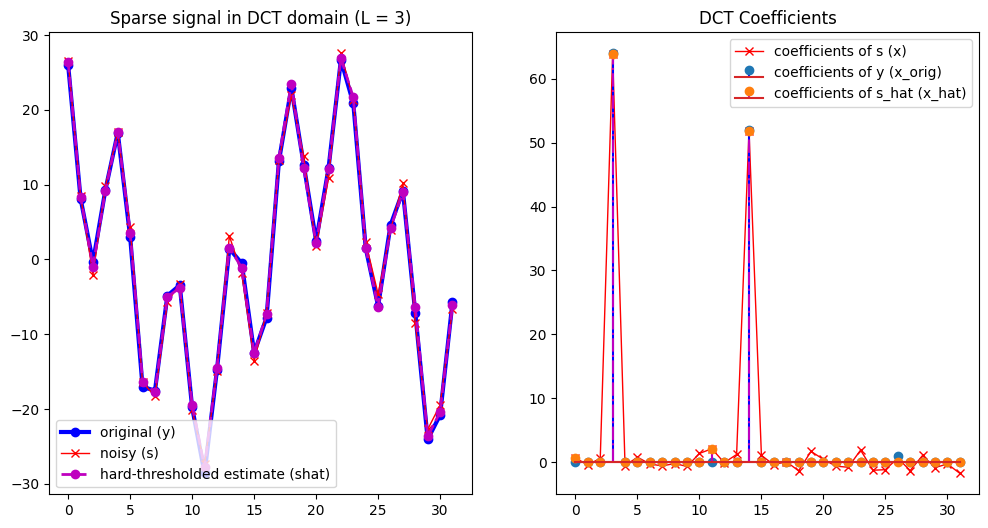

In [424]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].plot(y, 'b-o', linewidth=LN_WDT+1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT-1)
ax[0].plot(s_hat, 'm--o', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal in DCT domain (L = {L:.0f})')
ax[0].legend(['original (y)', 'noisy (s)', 'hard-thresholded estimate (shat)'])



ax[1].plot(x, 'r-x', linewidth=LN_WDT-1)
ax[1].stem(x_orig, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_hat, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('DCT Coefficients')
ax[1].legend(['coefficients of s (x)', 'coefficients of y (x_orig)', 'coefficients of s_hat (x_hat)'])


# Sparsity w.r.t redundant dictionary $A = [C,D]$

In this section you will perform the same denoising as in the previous section with the only difference that the signal $s = y + \eta$ that you will generate is sparse w.r.t. a redoundant dictionary $A=[C, D] \in\mathbb{R}^{M \times N}$, where $C\in\mathbb{M\times M}$ is the matrix representity the canonical basis, and $D\in\mathbb{M\times M}$ is the usual 1D-DCT matrix. Therefore $A$ is a rectangular matrix, since $M < N$.

To generate signals that are sparse w.r.t. $A=[C, D]$, at first generate a signal $y$ that is $L-1$ sparse w.r.t. $D$ as you have done in the previous section. Then, add a spike to $y$ that is sparse w.r.t. $A$. Bear in mind that the spike is to be considered a signal to be reconstructed, rather than noise.

Generate the standard orthonormal basis

Text(0.5, 1.0, 'Canonical basis dimension n = 32')

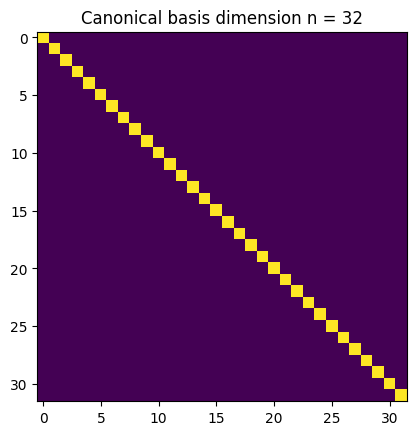

In [425]:
for i in range(M):
    a = np.zeros(M)
    a[i]=1
    C[:, i] = a  

plt.figure(5)
plt.imshow(C)
plt.title(f'Canonical basis dimension n = {M}')




Generate a signal that is sparse w.r.t. D

In [426]:
x_orig = np.zeros(M)
for i in range(L):
    loc = np.random.randint(M-1)
    if x_orig[loc] != 0:
        i= i -1
    x_orig[loc] = np.random.randint(1,100) # Change the coefficient

y = D @ x_orig

Randomly place a spike in the first 20 samples of $y$


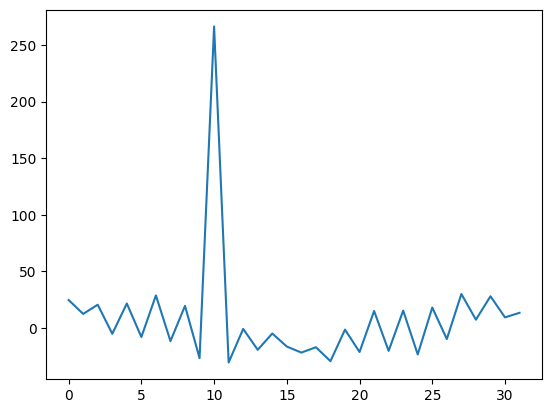

In [ ]:
# choose spike location
spikeLocation = np.random.randint(1, 20)   # I do not like spike at 0
# modify the signal intensity at spikeLocation
# update y
y[spikeLocation] = y[spikeLocation]*100

plt.plot(y)


Add noise to the signal

In [438]:
s = y + np.random.normal(0,1,M)*10

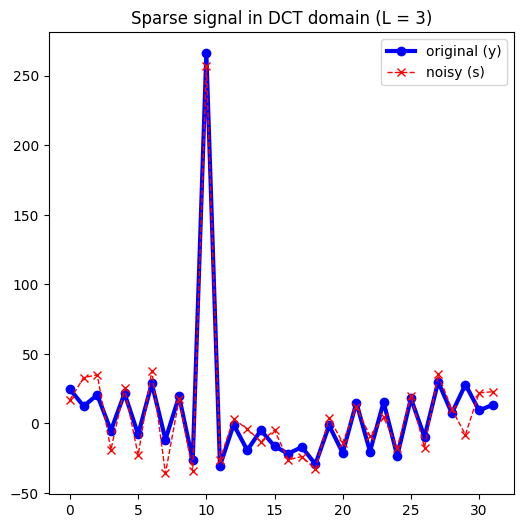

In [439]:

LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6,6))
plt.plot(y, 'b-o', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original (y)', 'noisy (s)'])


Perform hard thresholding by keeping the largest $L$ coefficients w.r.t. $D$ (not $A$!)

In [440]:
# analysis: compute the coefficients w.r.t. D
x = D.T @ s

# keep only the L largest coefficients (absolute value)
thresh = np.sort(np.abs(x))[-L]

x_hat = x * (np.abs(x)>= thresh)
x_hat[0] = x[0]

# invert the transformation
s_hat = D @ x

Plot the results and compare them to the one obtained in the previous section.

Is the signal $s$ denoised properly?

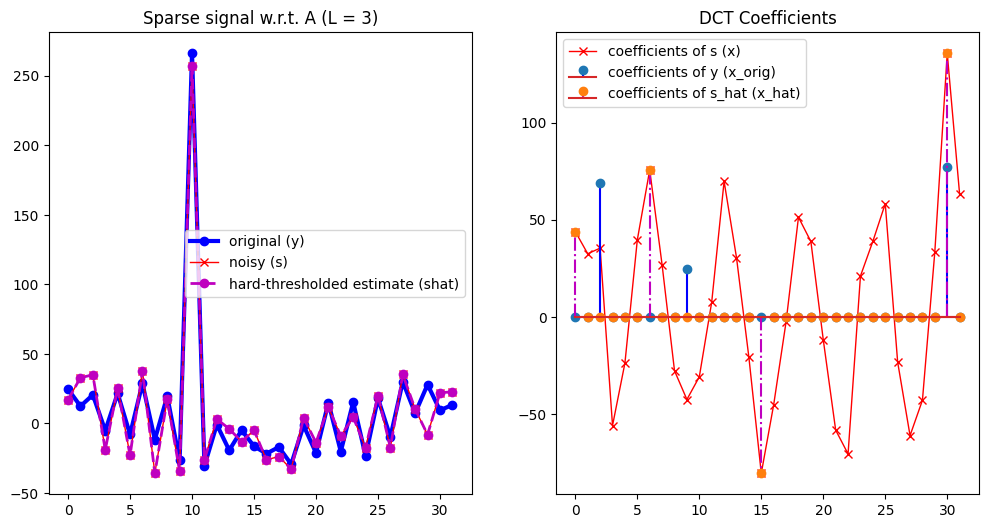

In [441]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].plot(y, 'b-o', linewidth=LN_WDT+1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT-1)
ax[0].plot(s_hat, 'm--o', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t. A (L = {L:.0f})')
ax[0].legend(['original (y)', 'noisy (s)', 'hard-thresholded estimate (shat)'])


ax[1].plot(x, 'r-x', linewidth=LN_WDT-1)
ax[1].stem(x_orig, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_hat, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('DCT Coefficients')
ax[1].legend(['coefficients of s (x)', 'coefficients of y (x_orig)', 'coefficients of s_hat (x_hat)'])

## Tichonov Regularization


Compute the representation w.r.t. $A = [C, D]$ using Tichonov's regularization (try differente value for $\lambda$)

In [442]:
lmbda = 1
x_hat_tic = np.linalg.inv(D.T @ D + lmbda * C)  @ D.T @ s
s_hat_tic = D  @ x_hat_tic


Show the results

Text(0.5, 1.0, 'Coefficients w.r.t. A')

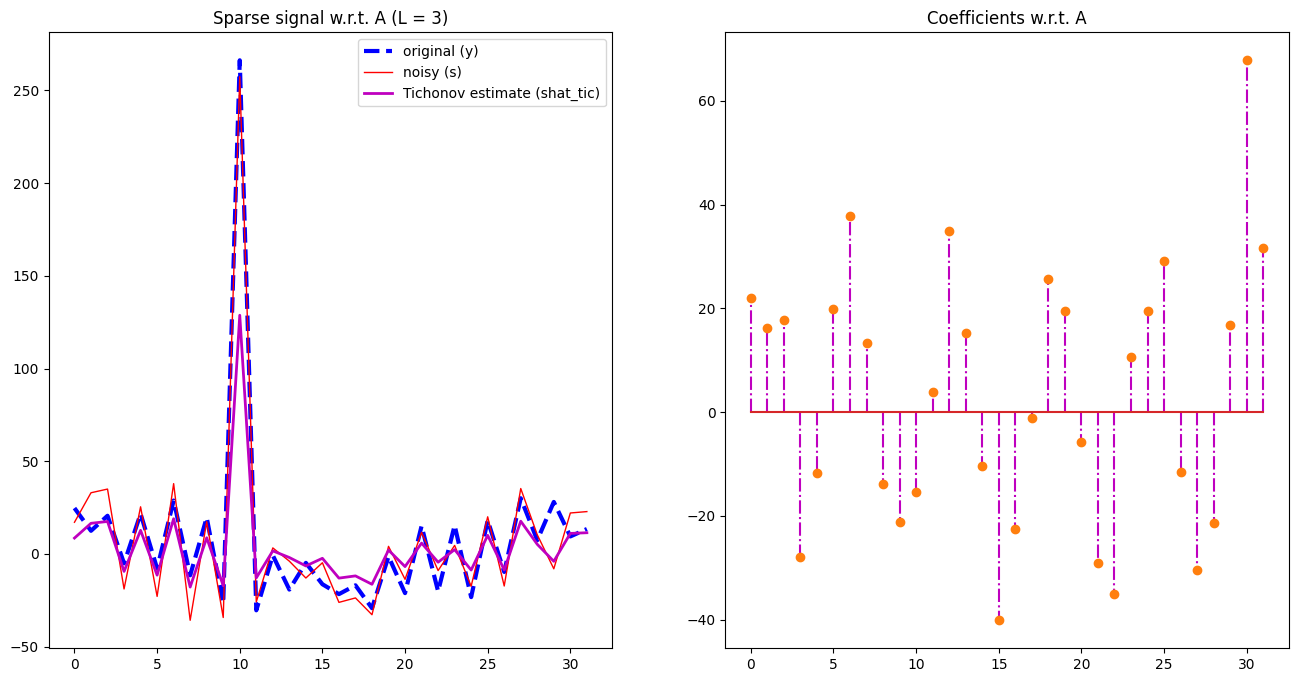

In [443]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(y, 'b--', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_tic, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t. A (L = {L:.0f})')
ax[0].legend(['original (y)', 'noisy (s)', 'Tichonov estimate (shat_tic)'])

ax[1].stem(x_hat_tic, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients w.r.t. A')